In [10]:
import pandas as pd
df = pd.read_csv('titanic.csv')

In [24]:
# df.loc[1,'Name'] # string
# df.loc[1,'Age'] # float
df.loc[1,'Survived'] # int

numpy.int64

In [25]:
import yfinance as yf
stock = yf.Ticker('FB')
df = stock.history(period='max')
#df = stock.history(start='2020-01-01', end='2020-09-15')

In [26]:
df.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2012-05-18,42.05,45.00,38.00,38.23,573576400,0,0
2012-05-21,36.53,36.66,33.00,34.03,168192700,0,0
2012-05-22,32.61,33.59,30.94,31.00,101786600,0,0
2012-05-23,31.37,32.50,31.36,32.00,73600000,0,0
2012-05-24,32.95,33.21,31.77,33.03,50237200,0,0


In [29]:
print(type(df.loc['2012-05-21','Close']))
print(type(df.iloc[1,3]))

<class 'numpy.float64'>
<class 'numpy.float64'>


In [7]:
print(df.iloc[2,3]) # implicit indexing 
print(df.loc['2012-05-22','Close']) # explict indexing 

31.0
31.0


In [31]:
df.index[1]

Timestamp('2012-05-21 00:00:00')

In [32]:
df.to_csv('FB.csv')

In [39]:
df = pd.read_csv('FB.csv', index_col='Date', parse_dates=True)
df.head(3)

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2012-05-18,42.05,45.00,38.00,38.23,573576400,0,0
2012-05-21,36.53,36.66,33.00,34.03,168192700,0,0
2012-05-22,32.61,33.59,30.94,31.00,101786600,0,0


In [41]:
df.index[1]

Timestamp('2012-05-21 00:00:00')

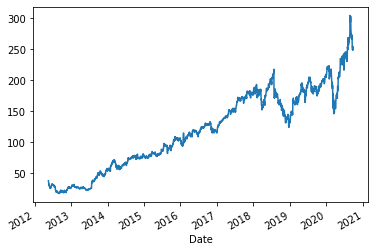

In [43]:
df.Close.plot()

In [44]:
'FB' + '.csv'

'FB.csv'

In [52]:
company = 'FB'
ext = '.csv'
print(company + ext) # string concatenation
print('%s%s' % (company, ext)) # placeholder
print('{}{}'.format(company, ext)) # string format
print(f'{company}{ext}') # f string 

FB.csv
FB.csv
FB.csv
FB.csv


In [57]:
import os
os.makedirs('data', exist_ok=True)

tickers = ['FB', 'AMZN', 'AAPL', 'NFLX', 'GOOGL'] # FAANG
for ticker in tickers:
    import yfinance as yf
    stock = yf.Ticker(ticker)
    df = stock.history(period='max')
    df.to_csv(f'data/{ticker}.csv')

In [68]:
df = pd.read_csv('data/FB.csv', index_col='Date', parse_dates=True)
df.rename(columns={"Close": "FB"}, inplace=True)
df.FB.head(3)

Date
2012-05-18    38.23
2012-05-21    34.03
2012-05-22    31.00
Name: FB, dtype: float64

In [73]:
df = pd.DataFrame()

tickers = ['FB', 'AMZN', 'AAPL', 'NFLX', 'GOOGL'] # FAANG
for ticker in tickers:
    df_ = pd.read_csv(f'data/{ticker}.csv',
                      index_col='Date',
                      parse_dates=True)
    df_.rename(columns={"Close": f"{ticker}"}, inplace=True)
    df_.drop(['Open','High','Low','Volume','Dividends','Stock Splits'],
             axis=1,
             inplace=True)
    
    if df.empty:
        df = df_
    else:
        df = df.join(df_, how='outer')
        
df

,FB,AMZN,AAPL,NFLX,GOOGL
Date,,,,,
1980-12-12,NaN,NaN,0.10,NaN,NaN
1980-12-15,NaN,NaN,0.10,NaN,NaN
1980-12-16,NaN,NaN,0.09,NaN,NaN
1980-12-17,NaN,NaN,0.09,NaN,NaN
1980-12-18,NaN,NaN,0.09,NaN,NaN
...,...,...,...,...,...
2020-09-17,254.82,3008.73,110.34,470.20,1487.04
2020-09-18,252.53,2954.91,106.84,469.96,1451.09
2020-09-21,248.15,2960.47,110.08,487.35,1430.14


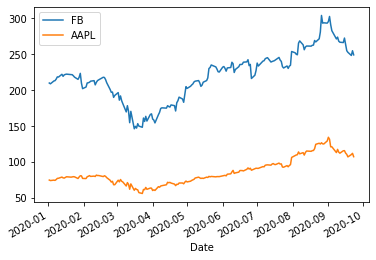

In [84]:
df.loc['2020-01-01':,['FB','AAPL']].plot()